In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns
import seaborn.objects as so

from formulaic import Formula 

from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

In [10]:
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

# Regresión lineal y Cuadrados mínimos

### Ejercicio 1
Implementar una función que calcule la pendiente y la ordenada al origen de la recta de regresión lineal con las fórmulas vistas en clase:

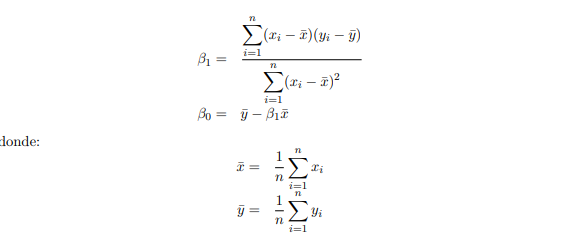

La función debe tomar como argumentos a x e y, que son _pandas.Series_ o _numpy.array_ , y devolver los valores de /beta_0 y /beta_1

**Sugerencia** : Recordar que dad un _pandas.Series_ se utiliza .mean() para calcular su promedio y recordar el uso de _np.sum_

In [24]:
def coefs_rl(x,y):
    beta_1 = (x*y).mean() - x.mean()*y.mean()  # Recordar que si x e y son np.arrays, la muliplicación es elemento a elemento.
    beta_0 = y.mean()- beta_1*x.mean()
    return beta_1, beta_0

In [25]:
x=np.array([1,2,3,4,5])
y=np.array([2,3,5,7,11])
coefs_rl(x,y)

(np.float64(4.400000000000002), np.float64(-7.600000000000007))

(b) Con el dataset _gapminder_ , utilizar la función implementada en el item anterior para realizar una regresión lineal entre los años y la expectativa de vida en Argentina. Comparar los coeficientes con los obtenidos por scikit-learn

In [26]:
datos = gapminder[gapminder['country']== 'Argentina']

datos

,country,year,pop,continent,lifeExp,gdpPercap
48,Argentina,1952,17876956.0,Americas,62.485,5911.315053
49,Argentina,1957,19610538.0,Americas,64.399,6856.856212
50,Argentina,1962,21283783.0,Americas,65.142,7133.166023
51,Argentina,1967,22934225.0,Americas,65.634,8052.953021
52,Argentina,1972,24779799.0,Americas,67.065,9443.038526
53,Argentina,1977,26983828.0,Americas,68.481,10079.026740
54,Argentina,1982,29341374.0,Americas,69.942,8997.897412
55,Argentina,1987,31620918.0,Americas,70.774,9139.671389
56,Argentina,1992,33958947.0,Americas,71.868,9308.418710
57,Argentina,1997,36203463.0,Americas,73.275,10967.281950


In [32]:
print(coefs_rl(datos['year'], datos['lifeExp']))

(np.float64(69.02979166668956), np.float64(-136575.41218754533))


In [28]:
y,X = Formula('year ~ lifeExp').get_model_matrix(datos)

In [29]:
# PREGUNTAR EN CLASE : ¿Hay algo mal con ésto o con la función coefs_rl? ¿Por qué dan tan distinto)?

modelo = sk.linear_model.LinearRegression(fit_intercept=False)
modelo.fit(X,y)
beta = modelo.coef_
beta


array([[1682.77208685,    4.29664238]])

### Ejercicio 2
En éste ejercicio trabajaremos con el dataset de inmuebles (_inmuebles.csv_ en la página de la materia). El dataset contiene datos sobre inmuebles que están a la venta en cierta ciudad : su superficie en m^2 , su precio en millones de pesos y la zona de la ciudad donde se encuentra. Recordar como cargar un dataset desde un .csv y visualizar sus primeras filas:

In [34]:
datos = pd.read_csv('datasets/inmuebles.csv')
datos.head()

,superficie,precio,zona
0,110.0,454.425690,Zona 2
1,109.0,383.004114,Zona 2
2,101.0,437.362638,Zona 2
3,58.0,304.392486,Zona 3
4,129.0,620.027722,Zona 3


(a) Realizar un gráfico de dispersión (scatterplot) que muestre la relación entre la superficie y el precio de cada inmueble.

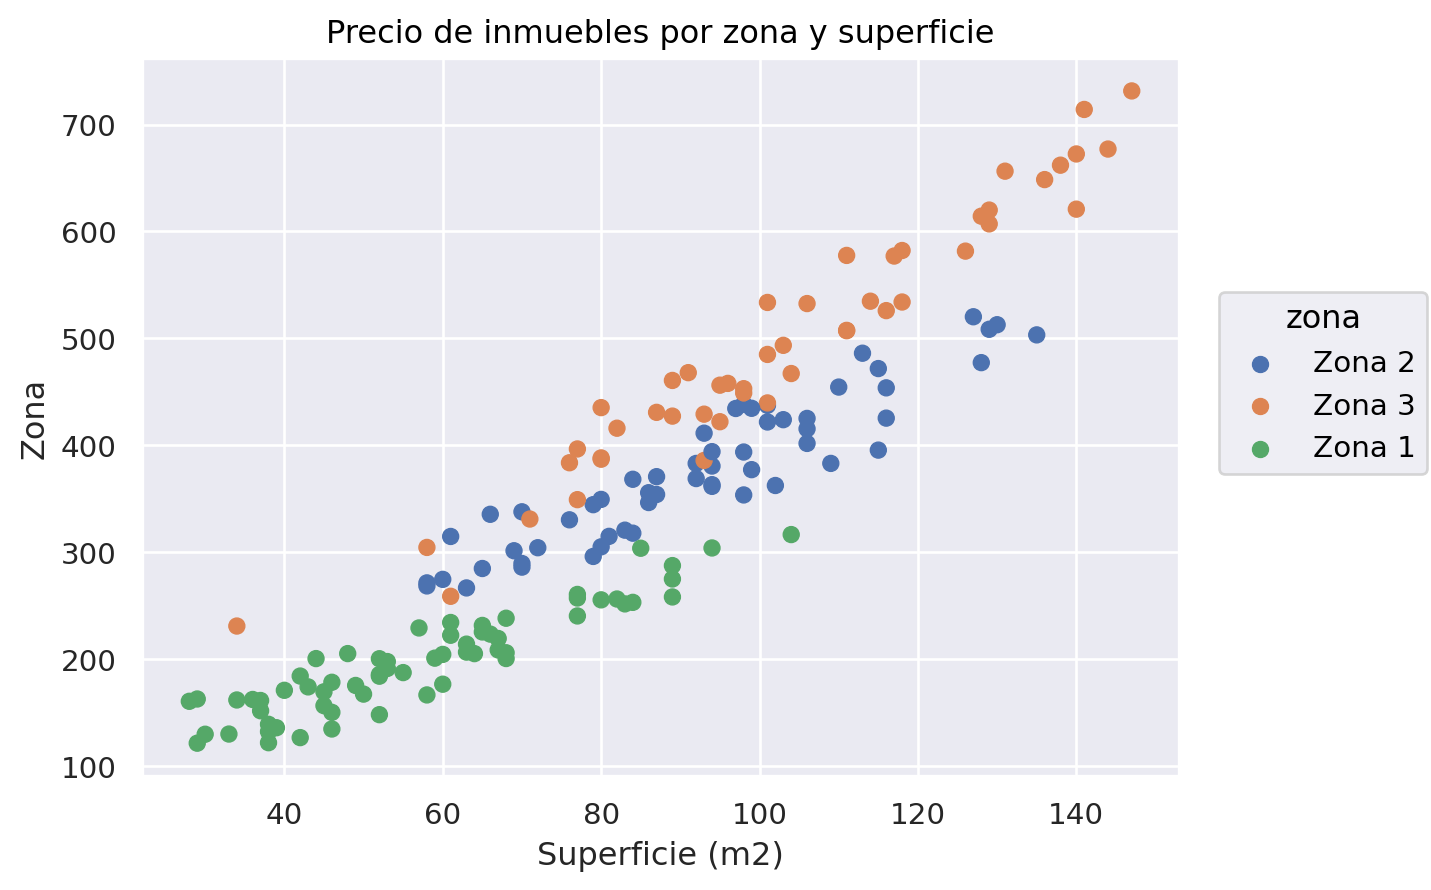

In [45]:
(
    so.Plot(
        datos, x = "superficie", y = "precio", color = "zona"
    )
    .add(so.Dot(),edgecolor="zona")
    .label(title="Precio de inmuebles por zona y superficie", x="Superficie (m2)", y="Zona")
)


(b)Realizar un gráfico de regresión lineal entre ambas variables. El gráfico debe titularse "Datos inmobiliarios" y la recta de Regresión lineal debe tener una leyenda que diga "Regresión"

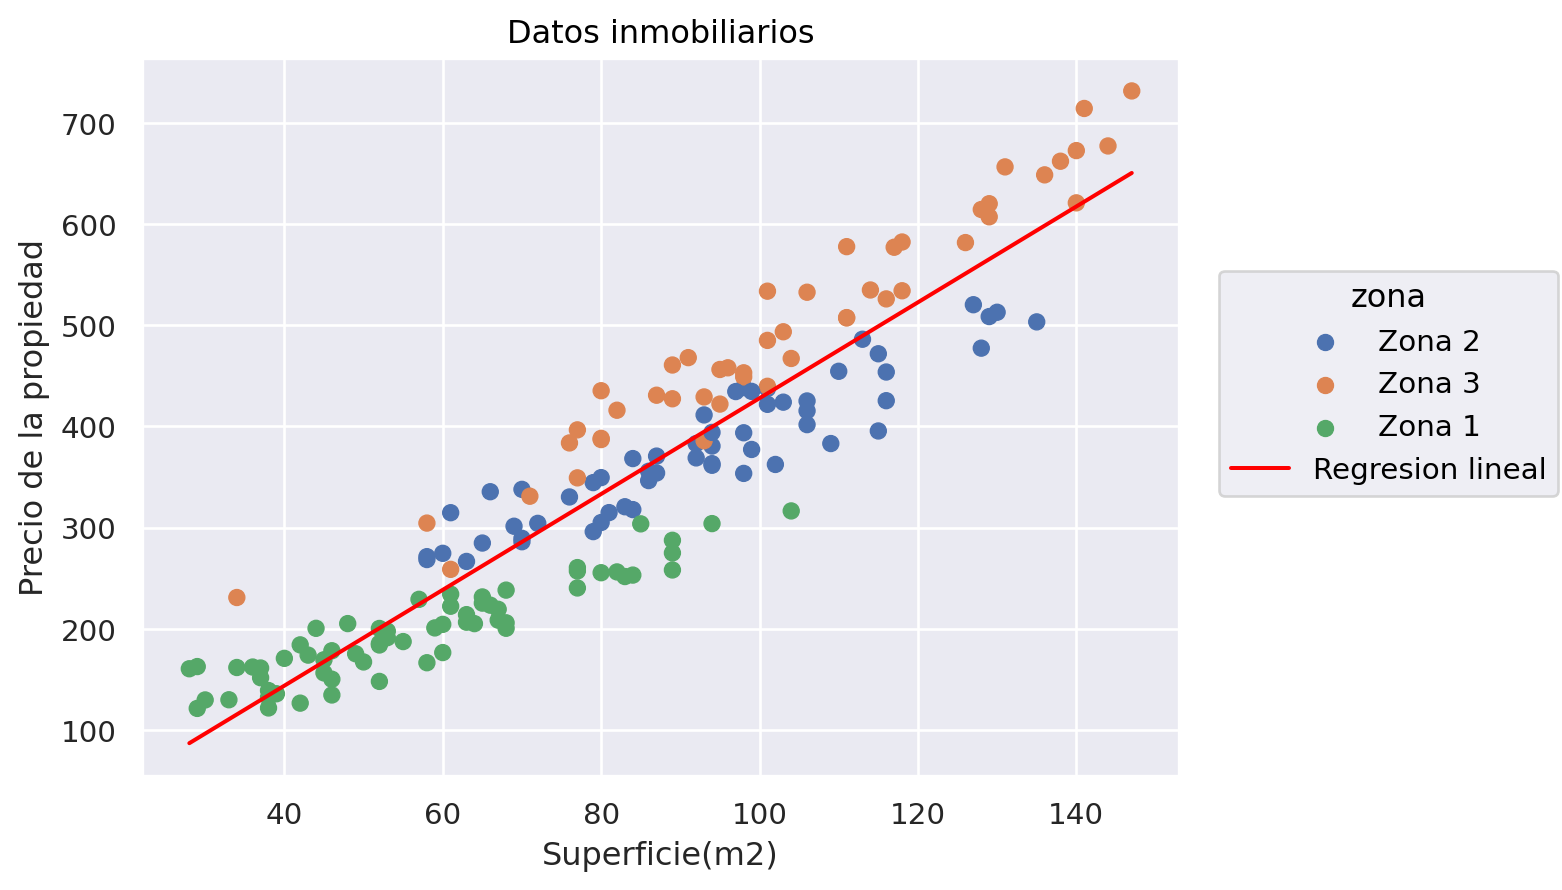

In [64]:
(
    so.Plot(data=datos, x='superficie', y='precio')
    .add(so.Dot(), color= 'zona')
    .add(so.Line(color = 'red'),so.PolyFit(1), label='Regresion lineal')
    .label(title='Datos inmobiliarios', x='Superficie(m2)', y= 'Precio de la propiedad')
)

(c) Calcular los coeficientes de la recta que mejor ajusta a los datos. Según el modelo , ¿Que podríamos interpretar sobre le costo del metro cuadrado en la ciudad?

In [ ]:
# Preguntar en clase si la formula de Wilkinson está bien
y,X = Formula('superficie ~ precio').get_model_matrix(datos)
modelo = sk.linear_model.LinearRegression(fit_intercept=False)
modelo.fit(X,y)
beta = modelo.coef_
beta

array([[18.62503784,  0.18501881]])

(d) Para medir qué tan bien ajusta la recta de los datos, vamos a implementar dos funciones: Una que calcule el error cuadrático medio (ECM) y otra que calcule el coeficiente de determinación R^2. Recordemos que


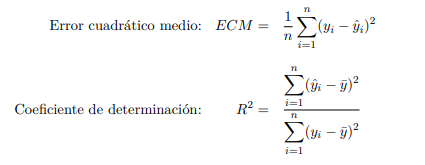

Para calcular ambas necesitamos los datos x,y y los coeficientes de la recta.

In [65]:
def ecm(x,y,pendiente,o_origen):
    y_pred = pendiente*x + o_origen
    return ((y-y_pred)**2).mean()

In [66]:
def r_cuad(x,y,pendiente,o_origen):
    y_pred = pendiente*x + o_origen
    return 1 - ((y-y_pred)**2).sum() / ((y-y.mean())**2).sum()

(e)Utilizando las funciones implementadas en el ítem anterior, calcular el ECM y el R^2 del ajuste realizado en el ítem b) ¿En qué unidades está cada medida? ¿Cómo podemos interpretarlas?

In [72]:
ecm(datos['superficie'], datos['precio'], beta[0, 1], beta[0, 0])

np.float64(115488.24848176142)

In [73]:
r_cuad(datos['superficie'], datos['precio'], beta[0, 1], beta[0, 0])

np.float64(-4.4338657889904605)

![Alt Text](https://media1.tenor.com/m/EhQJkQpssrsAAAAd/james-doakes-dexter-dexter.gif)

(f) Comparar los resultados obtenidos en el ítem anterior con los proporcionados por r2_score y mean_squared_error de scikit-learn

In [79]:
r2 = r2_score(datos['superficie'], beta[0, 1]*datos['precio'] + beta[0, 0])
ecm = mean_squared_error(datos['superficie'], beta[0, 1]*datos['precio'] + beta[0, 0])

In [80]:
print(f"ECM:{ecm}", f"R^2:{r2}")

ECM:102.78555939937021 R^2:0.8762114698357936


(g) Mediante la confección de un boxplot, decidir en cual de las zonas hay mayor variabilidad de precios. ¿Hay algún outlier?

<Axes: xlabel='zona', ylabel='precio'>

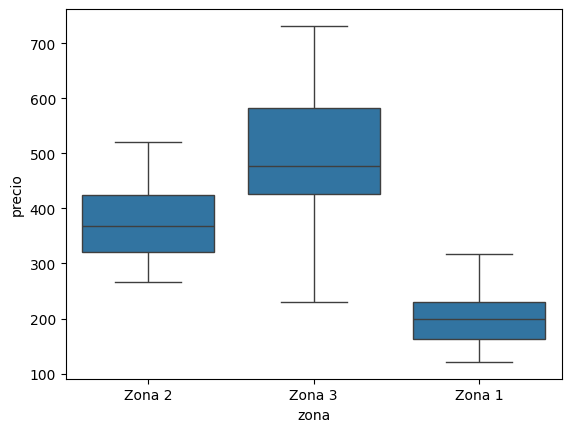

In [81]:
sns.boxplot(data=datos, x='zona',y= 'precio')

Por lo visto en la zona 3 hay una mayor variabilidad de precios, pero voy a ver si es porque hay outliers

In [90]:
datosZona3 = datos[datos['zona'] == 'Zona 3']
datosZona3.describe()

,superficie,precio
count,48.000000,48.000000
mean,103.354167,496.317738
std,25.031461,117.459158
min,34.000000,230.841020
25%,88.500000,425.942452
50%,101.000000,476.434559
75%,120.000000,581.762678
max,147.000000,731.493373


Como vimos en el gráfico anterior, hay una propiedad de la zona 3 que mide 34 m^2 de superficie y vale 230 millones de pesos. Lo cual tira muchísimo para abajo el promedio y aumenta mucho la variabildidad. En el gráfico del inciso (a) podemos ver como ,a pesar de que las propiedades en la zona 3 tienden a ser mas caras y mas grandes, ésta propiedad es una de las mas pequeñas y baratas de todo el dataset.

(h) Para cada una de las zonas de la ciudad, calcular los coeficientes, el ECM y R^2 de la recta que mejor aproxima a los datos.

In [95]:
# Para cada una de las zonas de la ciudad, calcular los coeficientes, el ECM y R^2 de la recta que mejor aproxima a los datos.

datosZona1 = datos[datos['zona'] == 'Zona 1']
datosZona2 = datos[datos['zona'] == 'Zona 2']
r2_zona1 = r2_score(datosZona1['superficie'], beta[0, 1]*datosZona1['precio'] + beta[0, 0])
ecm_zona1 = mean_squared_error(datosZona2['superficie'], beta[0, 1]*datosZona2['precio'] + beta[0, 0])
r2_zona2 = r2_score(datosZona2['superficie'], beta[0, 1]*datosZona2['precio'] + beta[0, 0])
ecm_zona2 = mean_squared_error(datosZona2['superficie'], beta[0, 1]*datosZona2['precio'] + beta[0, 0])
r2_zona3 = r2_score(datosZona3['superficie'], beta[0, 1]*datosZona3['precio'] + beta[0, 0])
ecm_zona3 = mean_squared_error(datosZona3['superficie'], beta[0, 1]*datosZona3['precio'] + beta[0, 0])

print(f"Zona 1: ECM:{ecm_zona1}, R^2:{r2_zona1}")
print(f"Zona 2: ECM:{ecm_zona2}, R^2:{r2_zona2}")
print(f"Zona 3: ECM:{ecm_zona3}, R^2:{r2_zona3}")

Zona 1: ECM:100.59421741259695, R^2:0.6557842261663733
Zona 2: ECM:100.59421741259695, R^2:0.7383823067800284
Zona 3: ECM:91.00277198487584, R^2:0.8516711553717171


(i) Graficar los datos y el ajuste lineal de cada zona utilizando el método facet() de Plot() (recordar el ejercicio 5.b de la práctica 3) ¿Cuál es el valor del metro cuadrado en cada zona? ¿Qué podemos concluir si comparamos éstos valores con lo obtenido en el item (c)?

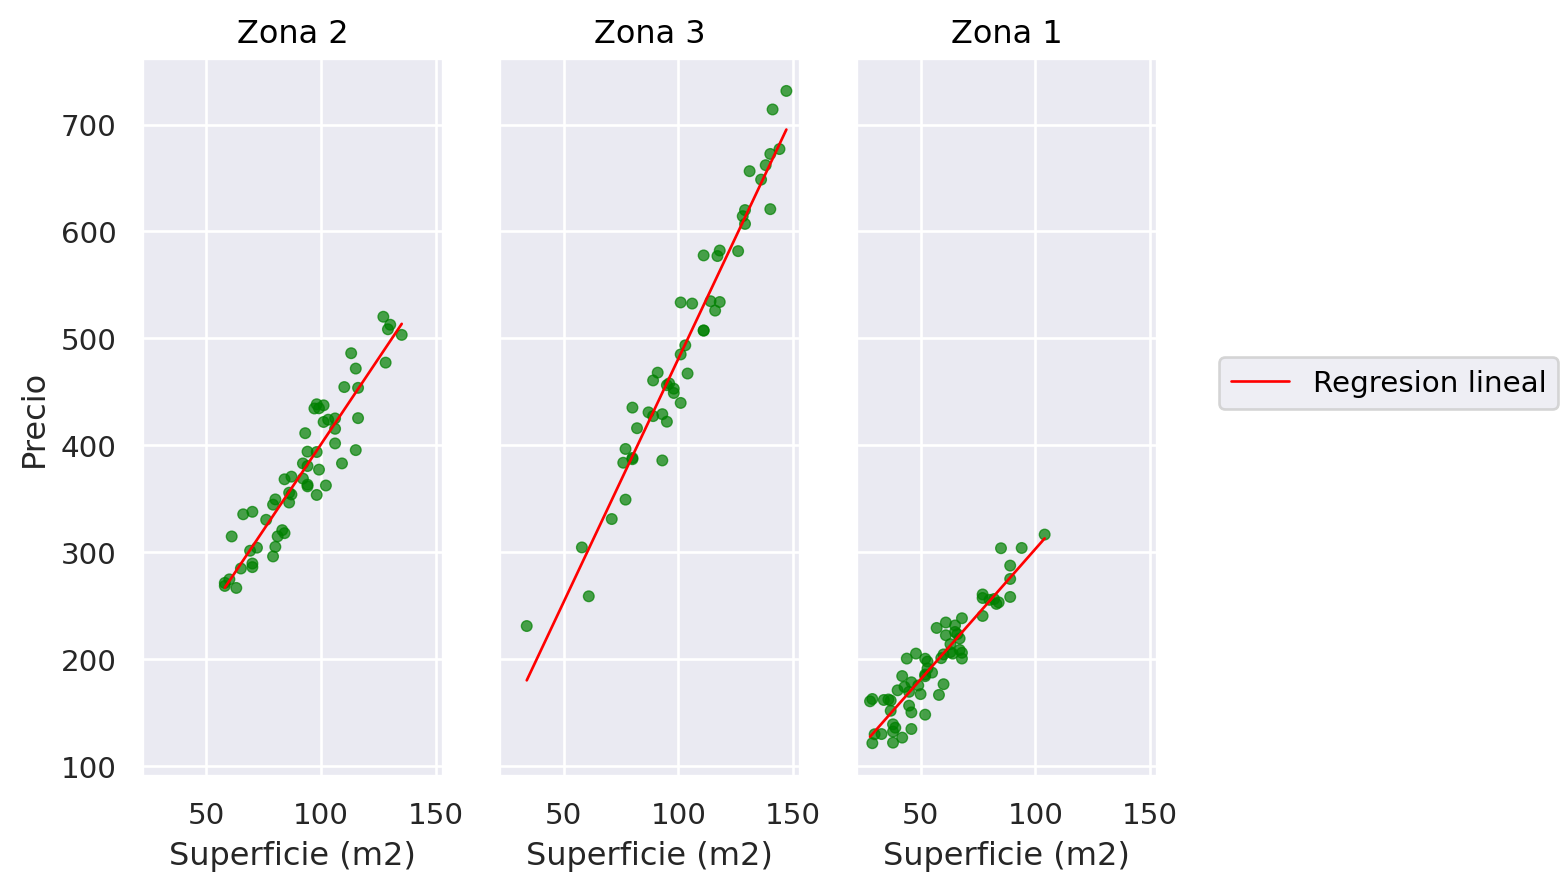

In [98]:
(
    so.Plot(datos, x = 'superficie',y ='precio')
    .add(so.Dot(pointsize=4,alpha=0.7,color='green'), group = 'zona')
    .add(so.Line(color='red', linewidth=1), so.PolyFit(1), label='Regresion lineal')
    .facet("zona",wrap=3)
        .label(
        x="Superficie (m2)",
        y="Precio",
    )
)

(j) Supongamos que queremos poner a la venta un inmueble de 105m^2. Sólo con esa información y teniendo en cuenta los items anteriores, ¿Cuál sería el precio de referencia para la venta? Si sabemos además que el inmueble está en la zona 2 ¿Cambiaría en algo el valor calculado anteriormente?

El precio de referencia sería de alrededor de unos 470 millones de pesos, para la zona 2. En la zona 3 el precio sería de unos 500 o 510 millones mientras que en la zona 1 el precio de referencia sería como máximo de unos 110 millones

(k) Supongamos que me ofrecen un inmueble de 100m^2 en la Zona 2 a un precio de 300 ¿Es caro o barato respecto a su precio de referencia?.

Es bastante barato, está al mismo precio que propiedades que tienen entre 60 y 70 metros cuadrados

(l)Efecto de los outliers. En éste item trabajaremos con los datos de inmuebles_outliers.csv, que tiene los mismos datos que inmuebles.csv, salvo cuatro que son outlier

Realizar un boxplot que permita identificar en qué zona(s) se encuentran los outliers.

<Axes: xlabel='zona', ylabel='precio'>

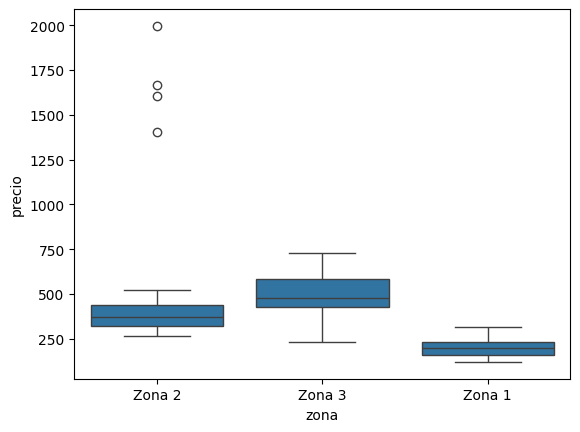

In [101]:
data = pd.read_csv('datasets/inmuebles_outliers.csv')
sns.boxplot(data, x= 'zona', y='precio')

#Como vemos los  outliers están en la zona 2.

(ii) Comparar los coeficientes del ajuste lineal de la zona afectada con los obtenidos en el item h)

In [103]:
#creo que hay que calcular beta de nuevo
y,X = Formula('superficie ~ precio').get_model_matrix(datos)
modelo = sk.linear_model.LinearRegression(fit_intercept=False)
modelo.fit(X,y)
beta = modelo.coef_
beta


datosZona1out = data[data['zona'] == 'Zona 1']
datosZona2out = data[data['zona'] == 'Zona 2']
datosZona3out = data[data['zona'] == 'Zona 3']
r2_zona1out = r2_score(datosZona1out['superficie'], beta[0, 1]*datosZona1out['precio'] + beta[0, 0])
ecm_zona1out = mean_squared_error(datosZona2['superficie'], beta[0, 1]*datosZona2out['precio'] + beta[0, 0])
r2_zona2out = r2_score(datosZona2out['superficie'], beta[0, 1]*datosZona2out['precio'] + beta[0, 0])
ecm_zona2out = mean_squared_error(datosZona2out['superficie'], beta[0, 1]*datosZona2out['precio'] + beta[0, 0])
r2_zona3out = r2_score(datosZona3out['superficie'], beta[0, 1]*datosZona3out['precio'] + beta[0, 0])
ecm_zona3out = mean_squared_error(datosZona3out['superficie'], beta[0, 1]*datosZona3out['precio'] + beta[0, 0])

print(f"Zona 1: ECM:{ecm_zona1}, R^2:{r2_zona1}", f"Zona 1 outliers: ECM{ecm_zona1out}, R^2:{r2_zona1out}")
print(f"Zona 2: ECM:{ecm_zona2}, R^2:{r2_zona2}", f"Zona 2 outliers: ECM{ecm_zona2out}, R^2:{r2_zona2out}")
print(f"Zona 3: ECM:{ecm_zona3}, R^2:{r2_zona3}", f"Zona 1 outliers: ECM{ecm_zona3out}, R^2:{r2_zona3out}")

Zona 1: ECM:100.59421741259695, R^2:0.6557842261663733 Zona 1 outliers: ECM3935.0854184547625, R^2:0.6557842261663733
Zona 2: ECM:100.59421741259695, R^2:0.7383823067800284 Zona 2 outliers: ECM3935.0854184547625, R^2:-9.234067089335133
Zona 3: ECM:91.00277198487584, R^2:0.8516711553717171 Zona 1 outliers: ECM91.00277198487584, R^2:0.8516711553717171


### Ejercicio 3
Creo que ya está hecho en clase

### Ejercicio 4
En el archivo _bitcoin.csv_ se encuentran datos de cotización de Bitcoin desde el 17/09/2014 hasta el 19/02/2022. Cargamos el dataset:

In [105]:
btc = pd.read_csv('datasets/bitcoin.csv')
btc.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


Nos interesa analizar la evolución del precio de cierre (Close) en período comprendido entre el 01/01/01 y el 01/07/2021

In [106]:
btc['Date']= pd.to_datetime(btc['Date'],format='%Y-%m-%d')

btc_2021 = btc[(btc['Date'] >= '2021-01-01') & (btc['Date'] <= '2021-12-31')]

Visualizar el ajuste lineal para los datos del dataframe btc_2021. En éste caso ,¿resulta más conveniente un scatterplot o un gráfico de líneas para los datos? ¿ Te resultaría util utilizar ésta recta para predecir el valor de BTC o para describir el cambio de su valor en éste período?

In [ ]:
(
    so.Plot(btc_2021, x= 'Date', y= 'Close')
    .add(so.Dot(),color = 'orange')
    .add(so.Line(),color= 'blue')
)

ValueError: Could not interpret value `orange` for `color`. An entry with this name does not appear in `data`.